In [11]:
import numpy as np
import pandas as pd
import antropy as ant
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import xgboost as xgb

In [12]:
df = pd.read_csv(r"D:\Datasets\BEED_Data.csv")

X = df.drop("y", axis=1)
y = df["y"]

print("Dataset shape:", X.shape)

Dataset shape: (8000, 16)


In [13]:
X["mean"] = X.mean(axis=1)
X["std"] = X.std(axis=1)
X["var"] = X.var(axis=1)
X["max"] = X.max(axis=1)
X["min"] = X.min(axis=1)
X["range"] = X["max"] - X["min"]

In [14]:
def hjorth(signal):

    signal = np.array(signal)

    d1 = np.diff(signal)
    d2 = np.diff(d1)

    var0 = np.var(signal)+1e-8
    var1 = np.var(d1)+1e-8
    var2 = np.var(d2)+1e-8

    activity = var0
    mobility = np.sqrt(var1/var0)
    complexity = np.sqrt(var2/var1)/mobility

    return activity, mobility, complexity


activity=[]
mobility=[]
complexity=[]

for row in X.values:

    a,m,c = hjorth(row)

    activity.append(a)
    mobility.append(m)
    complexity.append(c)

X["hjorth_activity"]=activity
X["hjorth_mobility"]=mobility
X["hjorth_complexity"]=complexity

In [15]:
entropy_feats=[]

for row in X.values:

    try:
        features=[
            ant.sample_entropy(row),
            ant.app_entropy(row),
            ant.perm_entropy(row,normalize=True),
            ant.spectral_entropy(row,sf=100,method="fft")
        ]
    except:
        features=[0,0,0,0]

    entropy_feats.append(features)

entropy_feats=np.array(entropy_feats)

entropy_feats=np.nan_to_num(entropy_feats)

In [16]:
X = np.concatenate([X.values, entropy_feats], axis=1)

y = y.values

print("Total Features:", X.shape[1])

Total Features: 29


In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
selector = SelectKBest(mutual_info_classif,k=25)

X_train = selector.fit_transform(X_train,y_train)
X_test = selector.transform(X_test)

In [20]:
rf = RandomForestClassifier(n_estimators=500)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test,rf_pred)

In [21]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train,y_train)

lr_acc = accuracy_score(y_test,lr.predict(X_test))

In [22]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

knn_acc = accuracy_score(y_test,knn.predict(X_test))

In [23]:
svm = SVC(kernel="rbf")

svm.fit(X_train,y_train)

svm_acc = accuracy_score(y_test,svm.predict(X_test))

In [25]:
xgb_model = xgb.XGBClassifier(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train,y_train)

xgb_acc = accuracy_score(y_test,xgb_model.predict(X_test))

In [26]:
print("Logistic Regression:",lr_acc)
print("KNN:",knn_acc)
print("Random Forest:",rf_acc)
print("SVM:",svm_acc)
print("XGBoost:",xgb_acc)

Logistic Regression: 0.630625
KNN: 0.9425
Random Forest: 0.95
SVM: 0.736875
XGBoost: 0.9175


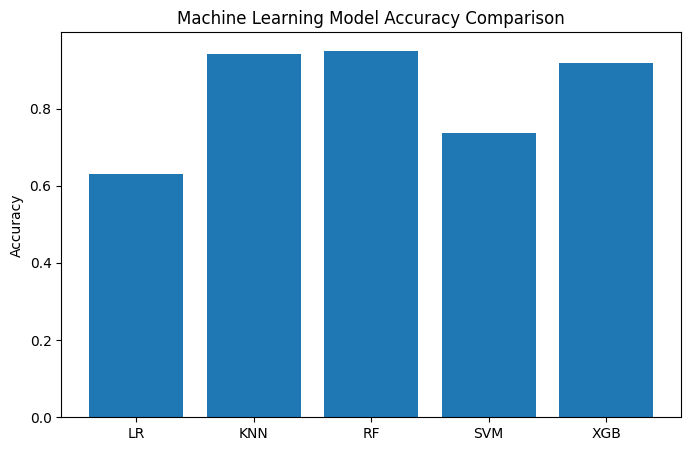

In [27]:
models=["LR","KNN","RF","SVM","XGB"]
scores=[lr_acc,knn_acc,rf_acc,svm_acc,xgb_acc]

plt.figure(figsize=(8,5))

plt.bar(models,scores)

plt.title("Machine Learning Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()